In [1]:
%load_ext autoreload
%autoreload 2

In [59]:
import numpy as np
import CustomModules.util as util
import plotly.express as px
import torch.nn as nn
import torch
import CustomModules.A_CAE as A_CAE
import CustomModules.A_AE as A_AE
from datasets import load_dataset
import matplotlib.pyplot as plt
from sklearn.datasets import make_s_curve

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [73]:
s_data, _ = make_s_curve(n_samples=1000, noise=0.05, random_state=0)
s_data_test, _ = make_s_curve(n_samples=1000, noise=0.05, random_state=1)
util.plot3d([(s_data, "S-Curve Dataset")], title="Double Torus") 

In [74]:
torus_data = util.generate_torus(1000)
torus_data_test = util.generate_torus(1000)
util.plot3d([(torus_data, "torus data")], title="Double Torus", color="blue")

In [75]:
X_train = torch.tensor(s_data, dtype=torch.float32)
X_test = torch.tensor(s_data_test, dtype=torch.float32)
X_loader_train = torch.utils.data.DataLoader(X_train, batch_size=1024, shuffle=True)
X_loader_test = torch.utils.data.DataLoader(X_test, batch_size=1024, shuffle=True)

In [76]:
ae = A_AE.AE(3,15,3)

In [77]:
A_AE.train_ae(num_epochs=1000, x_train_loader=X_loader_train, network=ae, device=device)

100%|██████████| 1000/1000 [00:05<00:00, 196.87it/s]


In [ ]:

cae = A_CAE.CAE(3, 20, 2, 20, 20, 20, 1)
A_CAE.pre_train_cae(num_epochs=50, x_train=X_train, network=cae, device=device)
diag = A_CAE.train_cae(num_epochs=1000, x_train_loader=X_loader_train, network=cae, device=device)

D:\Documents_D\Geometric-Deep-Learning\src\CustomModules\A_CAE.py:94: UserWarning: Using a target size (torch.Size([3])) that is different to the input size (torch.Size([1, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss += F.mse_loss(x_recon, x[i]) + F.mse_loss(z_latent, torch.zeros_like(z_latent)+0.5) - torch.log(network.predict(x)[i, i] + 1e-8)
100%|██████████| 1000/1000 [00:11<00:00, 85.45it/s]


In [118]:

def reconstruct(model_name, data):
    if model_name == "ae":
        ae.to("cpu")
        reconstructed = ae.decode(ae.encode(data)).detach().numpy()
        reconstructed.shape
    if model_name == "cae":
        cae.to("cpu")
        reconstructed = cae.encode_decode(data).detach().numpy()
    return reconstructed
util.plot3d([(reconstruct("cae", X_test), "reconstructed"), (X_test, "original")], title="Double Torus")

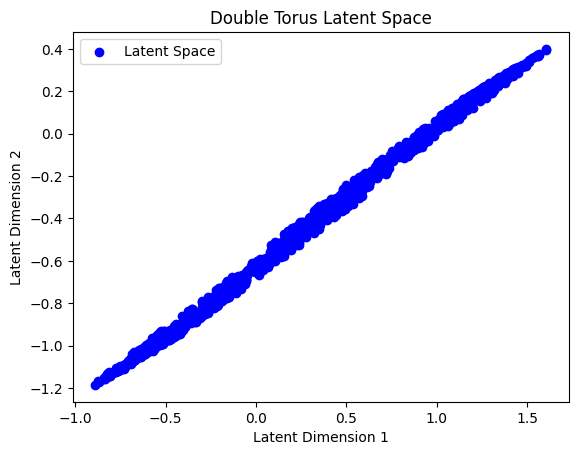

In [116]:
latent = cae.encode(X_test).detach().numpy()
plt.scatter(latent[:, 0], latent[:, 1], c='blue', label='Latent Space')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Double Torus Latent Space')
plt.legend()
plt.show()

In [ ]:
reps, _ = util.farthest_point_sample(torus_data, 10)
util.plot3d([(torus_data, "torus data"), (reps, "cluster centers")], title="Double Torus")